# NFTGuard — Data-Driven NFT Wash-Trading Detection

**Real Ethereum-mainnet NFT sales**, collected live via the Alchemy NFT API
(`getNFTSales`). Every row is a real on-chain transaction, verifiable on Etherscan
by its `txhash`.

Full standard ML pipeline: **collect → clean → EDA → feature engineering →
scaling & selection → train/test split → model selection → training →
evaluation & overfitting check → hyperparameter tuning → deployment & monitoring.**

## 1. Load the real dataset

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
import glob, os
sns.set_theme(style="whitegrid")

DATA = max(glob.glob("data/sales_raw*.csv"), key=os.path.getmtime)   # newest pull
df = pd.read_csv(DATA)
df["dt"] = pd.to_datetime(df["timestamp"], unit="s")
print("Dataset:", os.path.basename(DATA))
print("Loaded", len(df), "real NFT sales |", df["dt"].min().date(), "->", df["dt"].max().date())
df.head()

Dataset: sales_raw.new.csv
Loaded 3000 real NFT sales | 2023-07-04 -> 2024-04-30


,collection,contract,tokenId,buyer,seller,price_eth,marketplace,block,timestamp,txhash,dt
0,BoredApeYachtClub,0xBC4CA0EdA7647A8aB7C2061c2E118A18a936f13D,6218,0xf15c93562bc3944a68e938ef75d2a3360d98ca57,0xcc1cb0fa339eb32e436dce1ba752bda72fc6edfe,14.690,x2y2,19757649,1714353121,0x47908f6d62f3d1e924b7f21f07ad98dc80108be7fc23...,2024-04-29 01:12:01
1,BoredApeYachtClub,0xBC4CA0EdA7647A8aB7C2061c2E118A18a936f13D,1730,0x9d604a517750eecea2ee5c883d491449808a3498,0xf15c93562bc3944a68e938ef75d2a3360d98ca57,12.800,x2y2,19721684,1713917118,0xcb6e633ff54676a1ef3c7c782cfdbb74618c24351701...,2024-04-24 00:05:18
2,BoredApeYachtClub,0xBC4CA0EdA7647A8aB7C2061c2E118A18a936f13D,7845,0x8319e29b4693b0dbd6c2bc6a881d19c8caefbae1,0xf15c93562bc3944a68e938ef75d2a3360d98ca57,12.549,seaport,19716572,1713855146,0x536bf5e4efad23ad6d55c4c8b2264e5dd2e2751bdfd2...,2024-04-23 06:52:26
3,BoredApeYachtClub,0xBC4CA0EdA7647A8aB7C2061c2E118A18a936f13D,7232,0xed19eaea3bde70e0c9652485406fe961a85f4287,0x1e04bfb945dfa23ed8bdea67947ca0d7b5fff75d,14.500,x2y2,19713923,1713823032,0x306198aab98df7282e48df261907dd8ad7080f33f2fd...,2024-04-22 21:57:12
4,BoredApeYachtClub,0xBC4CA0EdA7647A8aB7C2061c2E118A18a936f13D,2063,0xc9aa3445ddb743219c930449d5fad7e8dd3f999e,0xf15c93562bc3944a68e938ef75d2a3360d98ca57,12.479,seaport,19690094,1713534154,0xafe5fd581a907192631d029196efa1c02de5e1181876...,2024-04-19 13:42:34


## 2. Data cleaning
Remove structural errors, handle missing values, remove duplicate transactions.

In [2]:
print("Raw rows:", len(df))
# structural errors: keep ETH-denominated sales with a positive price
df = df[df["price_eth"] > 0]
print("After removing non-ETH / zero-price rows:", len(df))
# missing values
b = len(df); df = df.dropna(subset=["buyer", "seller", "timestamp", "tokenId"])
print(f"After dropping rows with missing key fields: {len(df)} (-{b-len(df)})")
# duplicate transactions
b = len(df); df = df.drop_duplicates(subset=["txhash", "tokenId"])
print(f"After removing duplicate sales: {len(df)} (-{b-len(df)})")
df = df.sort_values("dt").reset_index(drop=True)
print("Missing values remaining:", int(df.isna().sum().sum()))

Raw rows: 3000
After removing non-ETH / zero-price rows: 2744
After dropping rows with missing key fields: 2744 (-0)
After removing duplicate sales: 2208 (-536)
Missing values remaining: 0


## 3. Exploratory data analysis

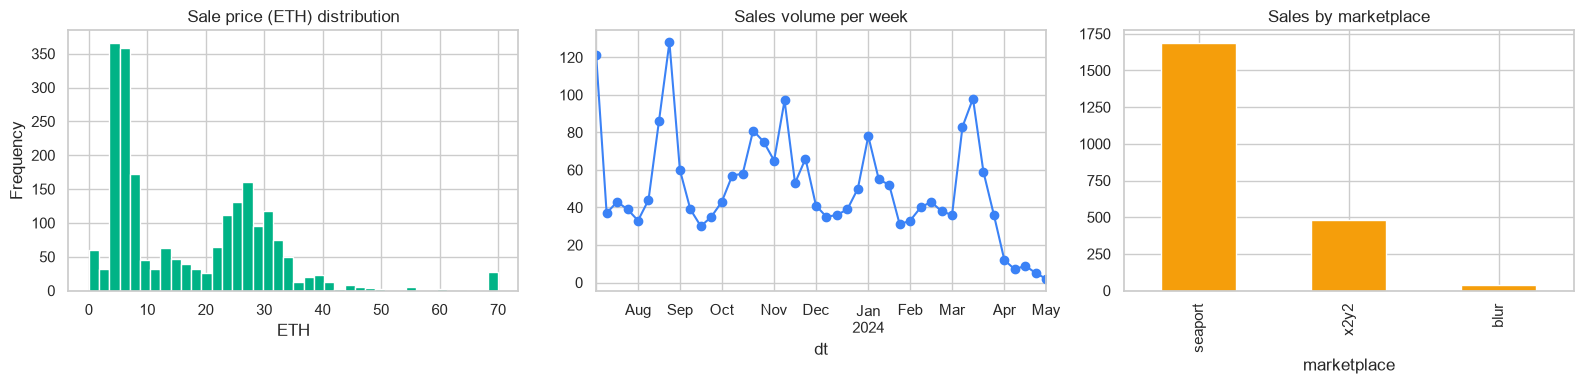

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
cap = df["price_eth"].quantile(0.99)
df["price_eth"].clip(upper=cap).plot.hist(bins=40, ax=ax[0], color="#00b386")
ax[0].set_title("Sale price (ETH) distribution"); ax[0].set_xlabel("ETH")
df.set_index("dt").resample("W")["price_eth"].count().plot(ax=ax[1], color="#3b82f6", marker="o")
ax[1].set_title("Sales volume per week")
df["marketplace"].value_counts().plot.bar(ax=ax[2], color="#f59e0b")
ax[2].set_title("Sales by marketplace"); plt.tight_layout(); plt.show()

## 4. Feature engineering — wash-trading fingerprints
- **is_self_transfer** — buyer == seller (fake volume)
- **pair_trade_count** — how often the same wallet pair trades back-and-forth (loops)
- **buyer/seller_activity** — how active each wallet is
- **price_z** — robust modified Z-score of the sale price within its collection
  (`0.6745 x (price - median) / MAD`), the same statistic the production backend uses
- **token_gap_h** — hours since the same token last sold (rapid re-flipping)

In [4]:
df["pair"] = [tuple(sorted(p)) for p in zip(df["buyer"], df["seller"])]
df["pair_trade_count"] = df["pair"].map(df["pair"].value_counts())
df["is_self_transfer"] = (df["buyer"] == df["seller"]).astype(int)
df["buyer_activity"]  = df["buyer"].map(df["buyer"].value_counts())
df["seller_activity"] = df["seller"].map(df["seller"].value_counts())
# Robust MODIFIED Z-score (median + MAD, Iglewicz-Hoaglin) -- identical to the
# backend's services/priceAnalyzer.js, so notebook and system cannot drift apart.
def modified_z(s):
    med = s.median()
    mad = (s - med).abs().median()
    if mad > 0:
        return 0.6745 * (s - med) / mad
    sd = s.std(ddof=1)
    return (s - s.mean()) / sd if sd > 0 else s * 0.0
df["price_z"] = df.groupby("collection")["price_eth"].transform(modified_z)
df["token_gap_h"] = df.groupby("tokenId")["dt"].diff().dt.total_seconds() / 3600
df["token_gap_h"] = df["token_gap_h"].fillna(df["token_gap_h"].median()).fillna(0)
df["mkt_code"] = df["marketplace"].astype("category").cat.codes
df[["is_self_transfer", "pair_trade_count", "buyer_activity",
    "seller_activity", "price_z", "token_gap_h"]].describe().round(2)

,is_self_transfer,pair_trade_count,buyer_activity,seller_activity,price_z,token_gap_h
count,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00
mean,0.24,1.18,4.17,6.50,0.46,620.09
std,0.43,0.68,5.89,11.26,4.50,707.52
min,0.00,1.00,1.00,1.00,-4.42,0.01
25%,0.00,1.00,1.00,1.00,-0.69,473.34
50%,0.00,1.00,2.00,2.00,0.00,473.34
75%,0.00,1.00,5.00,5.00,0.67,473.34
max,1.00,8.00,33.00,56.00,73.76,6355.58


## 5. Labeling (weak supervision)
No public ground-truth label exists for NFT wash trading. We label a sale **wash** if
it shows a canonical, hard-to-dispute pattern — a **self-transfer** or a wallet pair
that traded **back-and-forth 3+ times**.

> **Limitation (state in the report):** labels are heuristic-derived, not human-verified.

In [5]:
df["label_wash"] = ((df["is_self_transfer"] == 1) | (df["pair_trade_count"] >= 3)).astype(int)
print(df["label_wash"].value_counts())
print("suspicious share: %.1f%%" % (100 * df["label_wash"].mean()))

label_wash
0    1657
1     551
Name: count, dtype: int64
suspicious share: 25.0%


## 6. Feature scaling & selection
The model is trained on **economic/behavioural** features that **exclude** the indicators
used to define the label (`is_self_transfer`, `pair_trade_count`) — so it must *learn* to
detect wash trading, not memorise the rule. We standardise numeric ranges (mean 0, std 1)
so scale-sensitive models treat features equally, and check each feature's correlation
with the label to justify selection.

In [6]:
from sklearn.preprocessing import StandardScaler
FEATURES = ["price_eth", "price_z", "buyer_activity", "seller_activity", "token_gap_h", "mkt_code"]

corr = df[FEATURES + ["label_wash"]].corr()["label_wash"].drop("label_wash").sort_values()
print("Correlation of each feature with the wash label:\n", corr.round(3), "\n")

scaler = StandardScaler()
Xs = pd.DataFrame(scaler.fit_transform(df[FEATURES]), columns=FEATURES, index=df.index)
print("After scaling (mean ~0, std ~1):")
print(Xs.describe().loc[["mean", "std"]].round(2))

Correlation of each feature with the wash label:
 mkt_code          -0.246
seller_activity   -0.194
buyer_activity    -0.172
price_z           -0.120
price_eth         -0.068
token_gap_h        0.038
Name: label_wash, dtype: float64 

After scaling (mean ~0, std ~1):
      price_eth  price_z  buyer_activity  seller_activity  token_gap_h  \
mean       -0.0     -0.0            -0.0             -0.0          0.0   
std         1.0      1.0             1.0              1.0          1.0   

      mkt_code  
mean       0.0  
std        1.0  


## 7. Train / test split
70% to train the model, 30% held out to validate it. Stratified to keep the wash ratio balanced.

In [7]:
from sklearn.model_selection import train_test_split
y = df["label_wash"]
Xtr, Xte, ytr, yte = train_test_split(df[FEATURES], y, test_size=0.30, random_state=42, stratify=y)
Xtr_s, Xte_s = Xs.loc[Xtr.index], Xs.loc[Xte.index]   # scaled versions, same split
print("train:", len(Xtr), "| test:", len(Xte), "| wash train/test:", int(ytr.sum()), "/", int(yte.sum()))

train: 1545 | test: 663 | wash train/test: 386 / 165


## 8. Model selection & training
Random Forest (main) vs a scaled Logistic Regression baseline.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced").fit(Xtr, ytr)
lr = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr_s, ytr)   # LR needs scaling
print("Random Forest   ROC-AUC:", round(roc_auc_score(yte, rf.predict_proba(Xte)[:, 1]), 3))
print("LogReg (scaled) ROC-AUC:", round(roc_auc_score(yte, lr.predict_proba(Xte_s)[:, 1]), 3))
print("-> Random Forest wins; we proceed with it.")

Random Forest   ROC-AUC: 0.901
LogReg (scaled) ROC-AUC: 0.78
-> Random Forest wins; we proceed with it.


## 9. Evaluation & overfitting check

In [9]:
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
print(classification_report(yte, rf.predict(Xte), digits=3, target_names=["legit", "wash"]))
print("Train accuracy:", round(rf.score(Xtr, ytr), 3), "| Test accuracy:", round(rf.score(Xte, yte), 3))
cv = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"),
                     df[FEATURES], y, cv=5, scoring="roc_auc")
print("5-fold CV ROC-AUC: %.3f +/- %.3f" % (cv.mean(), cv.std()))
print("Test ROC-AUC close to CV ROC-AUC -> generalises well (Random Forests fit train ~1.0 by design;",
      "the test/CV gap is what matters).")

              precision    recall  f1-score   support

       legit      0.912     0.876     0.893       498
        wash      0.665     0.745     0.703       165

    accuracy                          0.843       663
   macro avg      0.788     0.810     0.798       663
weighted avg      0.851     0.843     0.846       663



Train accuracy: 0.99 | Test accuracy: 0.843


5-fold CV ROC-AUC: 0.864 +/- 0.024
Test ROC-AUC close to CV ROC-AUC -> generalises well (Random Forests fit train ~1.0 by design; the test/CV gap is what matters).


## 10. Hyperparameter tuning (GridSearchCV)

In [10]:
from sklearn.model_selection import GridSearchCV
grid = {"n_estimators": [200, 400], "max_depth": [None, 10, 20], "min_samples_leaf": [1, 3]}
gs = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"),
                  grid, cv=4, scoring="roc_auc", n_jobs=1)
gs.fit(Xtr, ytr)
best = gs.best_estimator_
print("Best params:", gs.best_params_)
print("Best CV ROC-AUC:", round(gs.best_score_, 3))
print("Tuned model test ROC-AUC:", round(roc_auc_score(yte, best.predict_proba(Xte)[:, 1]), 3))

Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 400}
Best CV ROC-AUC: 0.911
Tuned model test ROC-AUC: 0.896


### Confusion matrix & feature importance (tuned model)

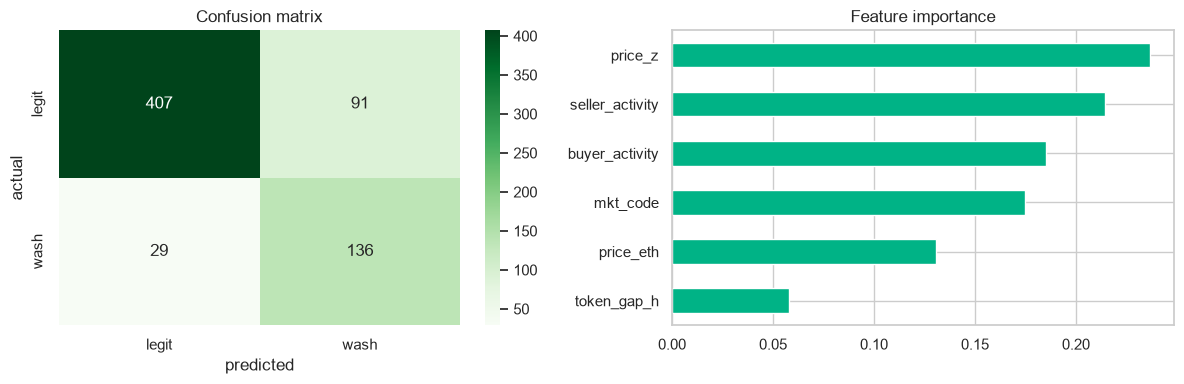

In [11]:
from sklearn.metrics import confusion_matrix
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(yte, best.predict(Xte)), annot=True, fmt="d", cmap="Greens", ax=ax[0],
            xticklabels=["legit", "wash"], yticklabels=["legit", "wash"])
ax[0].set_title("Confusion matrix"); ax[0].set_xlabel("predicted"); ax[0].set_ylabel("actual")
pd.Series(best.feature_importances_, index=FEATURES).sort_values().plot.barh(ax=ax[1], color="#00b386")
ax[1].set_title("Feature importance"); plt.tight_layout(); plt.show()

## 11. Unsupervised cross-check (Isolation Forest)
A label-free anomaly detector on the behavioural features, as a corroborating signal.

In [12]:
from sklearn.ensemble import IsolationForest
ISO = ["is_self_transfer", "pair_trade_count", "buyer_activity", "seller_activity"]
iso = IsolationForest(n_estimators=200, contamination=0.20, random_state=42)
df["anomaly"] = (iso.fit_predict(df[ISO].fillna(0.0)) == -1).astype(int)
rate = df.groupby("label_wash")["anomaly"].mean()
print("Flagged anomalous (no labels used): known wash %.1f%% vs other %.1f%%"
      % (100 * rate.get(1, 0), 100 * rate.get(0, 0)))

Flagged anomalous (no labels used): known wash 24.9% vs other 17.0%


### ROC and Precision-Recall curves

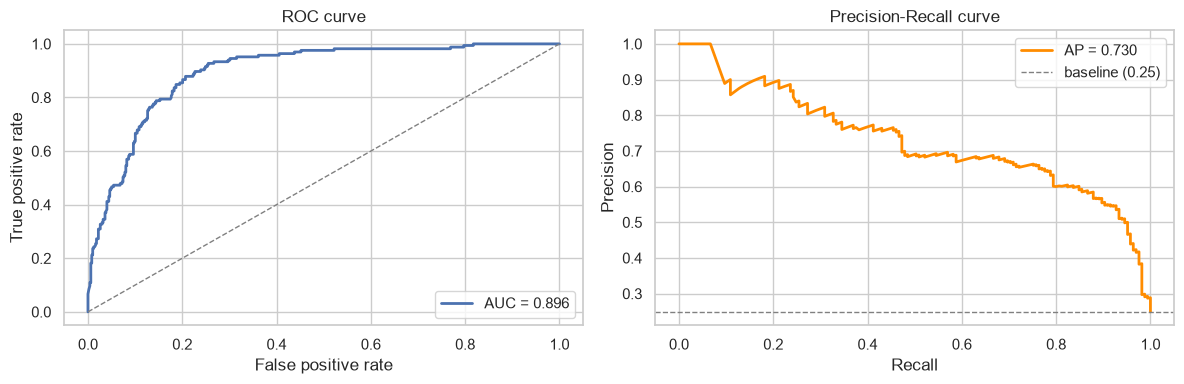

PR matters more than ROC here: only 25% of sales are wash, so a model can look strong on ROC while still producing many false positives.


In [13]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
proba = best.predict_proba(Xte)[:, 1]
fpr, tpr, _ = roc_curve(yte, proba)
prec, rec, _ = precision_recall_curve(yte, proba)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(fpr, tpr, lw=2, label="AUC = %.3f" % roc_auc_score(yte, proba))
ax[0].plot([0, 1], [0, 1], "--", color="grey", lw=1)
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC curve"); ax[0].legend()
ax[1].plot(rec, prec, lw=2, color="darkorange",
           label="AP = %.3f" % average_precision_score(yte, proba))
ax[1].axhline(y=yte.mean(), ls="--", color="grey", lw=1, label="baseline (%.2f)" % yte.mean())
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall curve"); ax[1].legend()
plt.tight_layout(); plt.show()
print("PR matters more than ROC here: only %.0f%% of sales are wash, so a model can look"
      % (100 * yte.mean()), "strong on ROC while still producing many false positives.")

## 12. The production risk model, reproduced on this dataset
Everything above detects **one** signal (wash trading). The deployed system combines
**three** indicators into a single 0-100 score. This section re-implements that exact
formula here, reading the very same `backend/config/thresholds.json` the server reads,
so the notebook and the running system cannot drift apart.

    weighted = 0.40*authRisk + 0.35*fraudRisk + 0.25*priceRisk
    Risk     = max(weighted, escalationFloor)

**Scope limit, stated honestly:** `authRisk` needs metadata hashes and images, which do
not exist in a sales CSV, so only `fraudRisk` and `priceRisk` are reproducible here.
Authenticity is validated against the live marketplace in section 14.

In [14]:
import json
TH = json.loads(Path("../backend/config/thresholds.json").read_text(encoding="utf-8"))
W  = TH["riskWeights"]; LV = TH["riskLevels"]
print("weights          :", W)
print("level cutoffs    : Low < %d <= Medium < %d <= High" % (LV["mediumFrom"], LV["highFrom"]))
print("z threshold      :", TH["priceAnomaly"]["zScoreThreshold"])
print("escalation curves:")
for k, v in LV["escalation"]["curves"].items():
    print("   %-13s %s" % (k, v))

weights          : {'authenticity': 0.4, 'fraud': 0.35, 'priceAnomaly': 0.25}
level cutoffs    : Low < 40 <= Medium < 70 <= High
z threshold      : 2.5
escalation curves:
   authenticity  [[100, 92]]
   fraud         [[45, 40], [80, 50], [100, 75]]
   price         [[45, 40], [70, 55], [90, 75], [100, 92]]


### 12.1 Price-anomaly risk
Identical to `priceRiskForToken()` in the backend: a sale is anomalous when `|Z| > 2.5`
on the robust modified Z-score, and the penalty grows with how far past the threshold it sits.

In [15]:
PA = TH["priceAnomaly"]
zT, base, per_anom, per_excess = (PA["zScoreThreshold"], PA["basePenalty"],
                                  PA["perAnomaly"], PA["perExcessZ"])
df["is_price_anom"] = df["price_z"].abs() > zT

def price_risk_for_token(g):
    a = g[g["is_price_anom"]]
    if a.empty:
        return 0.0
    max_z = a["price_z"].abs().max()
    return min(100.0, base + len(a) * per_anom + max(0.0, max_z - zT) * per_excess)

tok_price = df.groupby(["collection", "tokenId"]).apply(price_risk_for_token)
tok_price.name = "priceRisk"
print("tokens with a price anomaly: %d of %d (%.1f%%)"
      % ((tok_price > 0).sum(), len(tok_price), 100 * (tok_price > 0).mean()))
print(tok_price[tok_price > 0].describe().round(1).to_string())

tokens with a price anomaly: 198 of 1715 (11.5%)
count    198.0
mean      75.3
std       16.0
min       55.1
25%       61.0
50%       71.0
75%       89.3
max      100.0


### 12.2 Fraud risk, the four heuristic rules
The same rules as `services/fraudDetector.js`, with every penalty read from the config file.
All four are computable from sales data alone.

In [16]:
WT, AF, ST, RPE = TH["washTrade"], TH["abnormalFrequency"], TH["selfTransfer"], TH["rapidPriceEscalation"]

def fraud_risk_for_token(g):
    g = g.sort_values("dt"); risk = 0.0; fired = []
    if (g["pair"].value_counts() >= WT["loopPairMinCount"]).any():
        risk += WT["penalty"]; fired.append("loop")
    tv = (g["dt"].astype("int64") // 10**9).tolist()
    win = AF["windowMinutes"] * 60; mx = 1; j = 0
    for i in range(len(tv)):
        while tv[i] - tv[j] > win:
            j += 1
        mx = max(mx, i - j + 1)
    if mx >= AF["minCount"]:
        risk += AF["penalty"]; fired.append("freq")
    n_self = int(g["is_self_transfer"].sum())
    if n_self:
        risk += min(100, ST["penalty"] + max(0, n_self - 1) * ST.get("perExtra", 0))
        fired.append("self")
    pr = g["price_eth"].tolist()
    for i in range(1, len(pr)):
        if pr[i-1] > 0:
            inc = (pr[i] - pr[i-1]) / pr[i-1]
            if inc >= RPE["minIncreasePct"] and (tv[i] - tv[i-1]) / 60 <= RPE["windowMinutes"]:
                risk += RPE["penalty"]; fired.append("escal"); break
    return pd.Series({"fraudRisk": min(100.0, risk), "rules": ",".join(fired)})

tok_fraud = df.groupby(["collection", "tokenId"]).apply(fraud_risk_for_token)
print("tokens with any fraud rule fired: %d of %d (%.1f%%)"
      % ((tok_fraud["fraudRisk"] > 0).sum(), len(tok_fraud),
         100 * (tok_fraud["fraudRisk"] > 0).mean()))
print()
print("rule trigger counts:")
print(tok_fraud["rules"].str.get_dummies(sep=",").sum().sort_values(ascending=False).to_string())

tokens with any fraud rule fired: 544 of 1715 (31.7%)

rule trigger counts:
self     514
escal     42
freq      18


### 12.3 Unified score and the escalation floor
A weighted average caps any single indicator at its own weight: `priceRisk 100 x 0.25 = 25`
would read **Low**, and a proven fake (`authRisk 100 x 0.40 = 40`) only **Medium**. The
escalation gives each indicator its own interpolated curve so one decisive red flag can set
the verdict by itself. Below we measure how often it actually changes the outcome.

In [17]:
risk = tok_fraud.join(tok_price).fillna({"priceRisk": 0.0})
risk["authRisk"] = 0.0     # not derivable from a sales CSV - see section 14

# JavaScript's Math.round is half-UP; Python/NumPy round() is half-to-EVEN.
# The backend is Node, so 62.5 becomes 63 there but 62 here. Match Node exactly.
import math
def js_round(x):
    return int(math.floor(float(x) + 0.5))

def interp(value, curve):
    if value <= 0 or not curve:
        return 0.0
    if value < curve[0][0]:
        return 0.0
    for i, (x, yv) in enumerate(curve):
        if value == x:
            return float(yv)
        if value < x:
            px, py = curve[i-1]
            return py + (value - px) / (x - px) * (yv - py)
    return float(curve[-1][1])

CURVES = LV["escalation"]["curves"]
risk["weighted"] = (W["authenticity"] * risk["authRisk"] + W["fraud"] * risk["fraudRisk"]
                    + W["priceAnomaly"] * risk["priceRisk"]).map(js_round)
risk["floor"] = [max(interp(a, CURVES["authenticity"]), interp(f, CURVES["fraud"]),
                     interp(p, CURVES["price"]))
                 for a, f, p in zip(risk["authRisk"], risk["fraudRisk"], risk["priceRisk"])]
risk["unified"] = risk[["weighted", "floor"]].max(axis=1).map(js_round)
lvl = lambda v: "High" if v >= LV["highFrom"] else ("Medium" if v >= LV["mediumFrom"] else "Low")
risk["level"] = risk["unified"].map(lvl)
risk["level_weighted_only"] = risk["weighted"].map(lvl)

changed = int((risk["level"] != risk["level_weighted_only"]).sum())
print("tokens scored:", len(risk))
print(risk["level"].value_counts().reindex(["Low", "Medium", "High"]).fillna(0).astype(int).to_string())
print()
print("escalation changed the verdict for %d tokens (%.1f%%)" % (changed, 100 * changed / len(risk)))
print("without escalation the highest score any token could reach was %d" % risk["weighted"].max())
risk.sort_values("unified", ascending=False).head(8).round(1)

tokens scored: 1715
level
Low       1028
Medium     613
High        74

escalation changed the verdict for 676 tokens (39.4%)
without escalation the highest score any token could reach was 60


fraudRisk rules  priceRisk  authRisk  weighted  \
collection        tokenId                                                   
Azuki             308            0.0            100.0       0.0        25   
                  681            0.0            100.0       0.0        25   
                  7994           0.0            100.0       0.0        25   
                  9143           0.0            100.0       0.0        25   
                  8235           0.0            100.0       0.0        25   
                  8148           0.0            100.0       0.0        25   
BoredApeYachtClub 591            0.0            100.0       0.0        25   
                  8861           0.0            100.0       0.0        25   

                           floor  unified level level_weighted_only  
collection        tokenId                                            
Azuki             308       92.0       92  High                 Low  
                  681       92.0       92  High                 Low  
                  7994      92.0       92  High                 Low  
                  9143      92.0       92  High                 Low  
                  8235      92.0       92  High                 Low  
                  8148      92.0       92  High                 Low  
BoredApeYachtClub 591       92.0       92  High                 Low  
                  8861      92.0       92  High                 Low

### 12.4 Distribution of the unified risk score

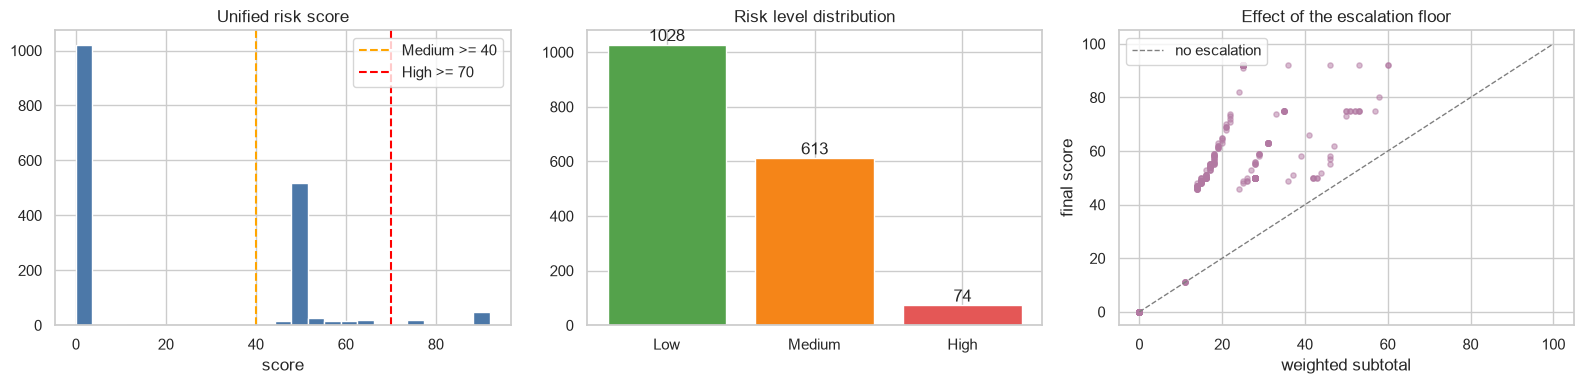

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(risk["unified"], bins=25, color="#4C78A8", edgecolor="white")
for cut, col, lab in [(LV["mediumFrom"], "orange", "Medium"), (LV["highFrom"], "red", "High")]:
    ax[0].axvline(cut, ls="--", color=col, label="%s >= %d" % (lab, cut))
ax[0].set_title("Unified risk score"); ax[0].set_xlabel("score"); ax[0].legend()

order = ["Low", "Medium", "High"]
counts = risk["level"].value_counts().reindex(order).fillna(0)
ax[1].bar(order, counts, color=["#54A24B", "#F58518", "#E45756"])
ax[1].set_title("Risk level distribution")
for i, v in enumerate(counts):
    ax[1].text(i, v, int(v), ha="center", va="bottom")

ax[2].scatter(risk["weighted"], risk["unified"], s=14, alpha=.5, color="#B279A2")
ax[2].plot([0, 100], [0, 100], "--", color="grey", lw=1, label="no escalation")
ax[2].set_xlabel("weighted subtotal"); ax[2].set_ylabel("final score")
ax[2].set_title("Effect of the escalation floor"); ax[2].legend()
plt.tight_layout(); plt.show()

## 13. Threshold sensitivity analysis
The Z-threshold is a **design choice**, not a measurement. Iglewicz & Hoaglin (1993)
recommend 3.5 for the modified Z-score; this project uses **2.5**, deliberately more
sensitive because missing fraud costs more than a false alarm. This sweep shows what that
choice costs and buys, turning "we picked 2.5" into a defensible finding.

 z_threshold  sales_flagged  pct_of_sales  caught_wash  recall_on_wash  false_alarms
         2.0            351         15.90           56            10.2           295
         2.5            217          9.83           11             2.0           206
         3.0            174          7.88            5             0.9           169
         3.5            137          6.20            5             0.9           132
         4.0            103          4.66            3             0.5           100


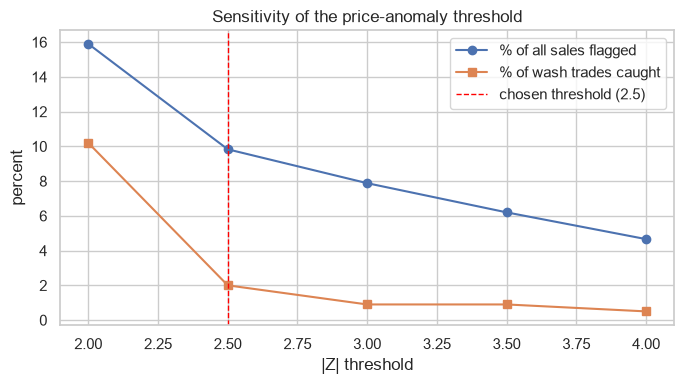

In [19]:
rows = []
n_wash = max(1, int((df["label_wash"] == 1).sum()))
for t in [2.0, 2.5, 3.0, 3.5, 4.0]:
    flagged = df["price_z"].abs() > t
    rows.append({"z_threshold": t,
                 "sales_flagged": int(flagged.sum()),
                 "pct_of_sales": round(100 * flagged.mean(), 2),
                 "caught_wash": int((flagged & (df["label_wash"] == 1)).sum()),
                 "recall_on_wash": round(100 * (flagged & (df["label_wash"] == 1)).sum() / n_wash, 1),
                 "false_alarms": int((flagged & (df["label_wash"] == 0)).sum())})
sens = pd.DataFrame(rows)
print(sens.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sens["z_threshold"], sens["pct_of_sales"], "o-", label="% of all sales flagged")
ax.plot(sens["z_threshold"], sens["recall_on_wash"], "s-", label="% of wash trades caught")
ax.axvline(2.5, ls="--", color="red", lw=1, label="chosen threshold (2.5)")
ax.set_xlabel("|Z| threshold"); ax.set_ylabel("percent"); ax.legend()
ax.set_title("Sensitivity of the price-anomaly threshold")
plt.tight_layout(); plt.show()

## 14. Cross-check against the live system
The formulas above are re-implementations. This section calls the running backend and
compares its scores against ours, which is the strongest evidence that the notebook and
production agree. Start the server first (`cd backend && npm start`); the cell degrades
gracefully if it is not running.

This check earned its keep: the first run disagreed on 7 of 48 tokens, all scoring 62 here
against 63 in the backend. The cause was rounding convention, not logic -- JavaScript's
`Math.round` rounds .5 **up** while Python/NumPy round to the nearest **even** number, so
62.5 became 63 in Node and 62 in pandas. The notebook now uses a `js_round` helper to match.

In [20]:
import urllib.request, json as _json
try:
    with urllib.request.urlopen("http://localhost:5000/api/nfts", timeout=8) as r:
        live = _json.loads(r.read().decode())
    rows = [{"tokenId": n["tokenId"], "name": n.get("name", "")[:26],
             "authRisk": n["risk"]["breakdown"]["authRisk"],
             "fraudRisk": n["risk"]["breakdown"]["fraudRisk"],
             "priceRisk": n["risk"]["breakdown"]["priceRisk"],
             "unified": n["risk"]["unifiedScore"], "level": n["risk"]["riskLevel"]}
            for n in live if n.get("risk")]
    L = pd.DataFrame(rows)
    L["our_weighted"] = (W["authenticity"] * L["authRisk"] + W["fraud"] * L["fraudRisk"]
                         + W["priceAnomaly"] * L["priceRisk"]).map(js_round)
    L["our_floor"] = [max(interp(a, CURVES["authenticity"]), interp(f, CURVES["fraud"]),
                          interp(p, CURVES["price"]))
                      for a, f, p in zip(L["authRisk"], L["fraudRisk"], L["priceRisk"])]
    L["our_unified"] = L[["our_weighted", "our_floor"]].max(axis=1).map(js_round)
    L["match"] = L["our_unified"] == L["unified"]
    print("live NFTs compared :", len(L))
    print("exact score matches: %d / %d (%.1f%%)"
          % (L["match"].sum(), len(L), 100 * L["match"].mean()))
    print(L["level"].value_counts().reindex(["Low", "Medium", "High"]).fillna(0).astype(int).to_string())
    mismatches = L[~L["match"]]
    print()
    print("mismatches:" if len(mismatches) else "no mismatches - notebook and backend agree exactly")
    display(mismatches.head() if len(mismatches) else L.head(8).round(1))
except Exception as e:
    print("Live backend not reachable (%s) - skipping cross-check." % type(e).__name__)
    print("Start it with:  cd backend && npm start")

live NFTs compared : 48
exact score matches: 48 / 48 (100.0%)
level
Low       23
Medium    14
High      11

no mismatches - notebook and backend agree exactly


,tokenId,name,authRisk,fraudRisk,priceRisk,unified,level,our_weighted,our_floor,our_unified,match
0,1,Azuki #4305,0,90,0,63,Medium,31,62.5,63,True
1,2,BoredApeYachtClub #3511,0,90,0,63,Medium,31,62.5,63,True
2,3,Azuki #8418,0,90,100,92,High,57,92.0,92,True
3,4,Azuki #6966,0,0,83,68,Medium,21,68.0,68,True
4,5,Azuki #7092,0,80,0,50,Medium,28,50.0,50,True
5,6,BoredApeYachtClub #9968,0,0,49,42,Medium,12,42.4,42,True
6,7,BoredApeYachtClub #6523,0,90,0,63,Medium,31,62.5,63,True
7,8,BoredApeYachtClub #9305,0,90,0,63,Medium,31,62.5,63,True


## 15. Deployment & monitoring
**Deployment:** the tuned model is saved to `ml/model.joblib`; `export_for_dashboard.py`
runs this pipeline and serves the results to the NFTGuard dashboard's **ML Detection**
view through the Node backend.

**Monitoring (production plan):** track (1) **data drift** — shifts in price/volume/wallet
distributions vs training; (2) **precision decay** — sample flagged trades for manual review
and watch the false-positive rate; (3) **scheduled retraining** as new labelled patterns
emerge; (4) alerting when the weekly wash-rate crosses a threshold.

In [21]:
import joblib
joblib.dump(best, "model.joblib")
print("Saved tuned model -> ml/model.joblib")

Saved tuned model -> ml/model.joblib


## 16. Summary
- Real on-chain data (verifiable on Etherscan), cleaned and feature-engineered.
- Random Forest detects wash trading from economic features with the tuned ROC-AUC above,
  validated by 5-fold cross-validation (no significant overfitting) and corroborated by an
  unsupervised detector.
- Honest limitation: weak-supervision labels; human-verified samples would strengthen evaluation.